# Anharmonic Lattice Dynamics (ALD) for (10,0) CNT with [Tersoff](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.81.205441)

## Import Necessary Packges

In [1]:
from ase.io import read
from pylab import *
import warnings
warnings.filterwarnings("ignore")

## Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequnecy or mean-free path

       input:
       observables: (ndarray) either phonon frequnecy or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

## Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

## Plot Phonon Spectra (Dispersion) and Density of State (DOS)

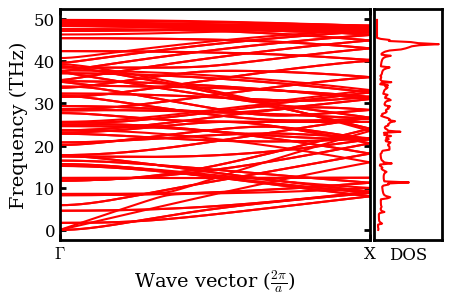

In [4]:
# Denote data path
data_folder = "./"

# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt(data_folder  + 'plots/1_1_151/dispersion')
point_names = np.loadtxt(data_folder  + 'plots//1_1_151/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt(data_folder  + 'plots/1_1_151/q')
Q = np.loadtxt(data_folder  + 'plots/1_1_151/Q_val')
dos_Si = np.load(data_folder  + 'plots/1_1_151/dos.npy')

fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'r-', ms=1)
plot(q, dispersion, 'r-', ms=1)
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 60, 10))
xticks(Q, point_names_list)
xlim([0, 0.5])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])
for d in np.expand_dims(dos_Si[1],0):
    dosax.plot(d, dos_Si[0],c='r')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
show()


# Plot Heat Capacity, Group Velocities and Phase Space

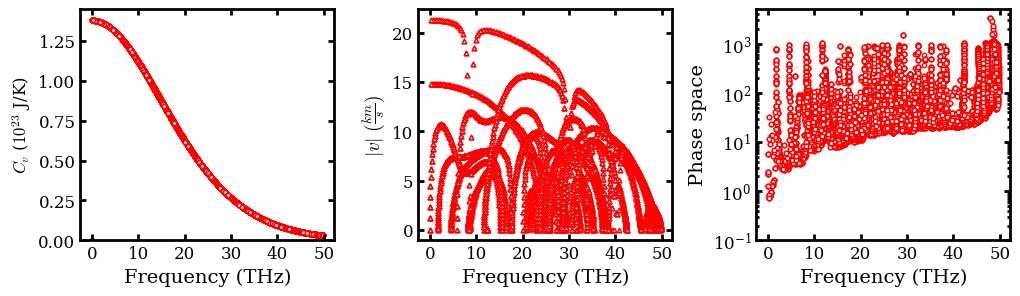

In [5]:
# Load in group velocity and frequency data
frequency =  np.load(
   data_folder  +  'ALD_CNT/1_1_151/frequency.npy',
    allow_pickle=True)


cv =  np.load(
   data_folder  + 'ALD_CNT/1_1_151/300/quantum/heat_capacity.npy',
    allow_pickle=True)


group_velocity = np.load(
   data_folder  +  'ALD_CNT/1_1_151/velocity.npy')


phase_space = np.load(data_folder  + 'ALD_CNT/1_1_151/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm = np.linalg.norm(
    group_velocity.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C')[3:], 1e23*cv.flatten(order='C')[3:], 
        facecolor='w', edgecolor='r', s=10, marker='8')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 60, 10))
ylim(0.35*1e23*cv.flatten(order='C')[3:].min(), 1.05*1e23*cv.flatten(order='C')[3:].max())

subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        group_velcotiy_norm, facecolor='w', edgecolor='r', s=10, marker='^')
gca().set_xticks(np.arange(0, 60, 10))
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        phase_space, facecolor='w', edgecolor='r', s=10, marker='o')
gca().set_xticks(np.arange(0, 60, 10))
ylabel('Phase space', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-1, 5e3])
subplots_adjust(wspace=0.33)
show()

## Visualize Phonon Life Time ($\tau$), Scattering Rate ($\Gamma$) $\&$ MFP ($\lambda$)
- Note that  $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

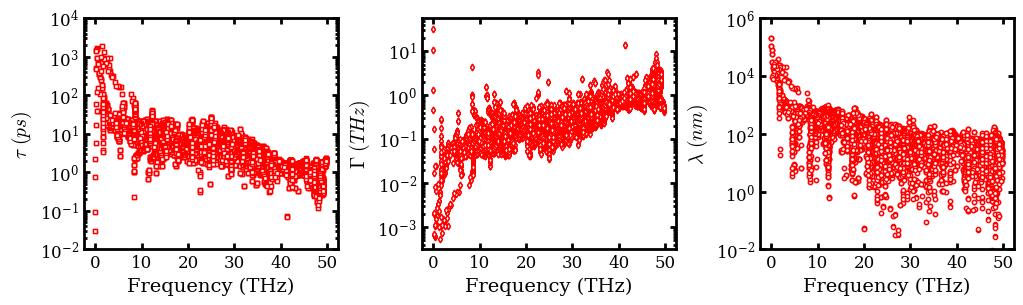

In [6]:
# Load in scattering rate
scattering_rate = np.load(
   data_folder  +  'ALD_CNT/1_1_151/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,1]

# Derive lifetime, which is inverse of scattering rate
life_time = scattering_rate ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path = []
for i in range(3):
    mean_free_path.append(np.loadtxt(
  data_folder  +   'ALD_CNT/1_1_151/inverse/300/quantum/mean_free_path_' +
    str(i) + '.dat'))


# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path = np.array(mean_free_path).T
mean_free_path_norm = np.linalg.norm(
    mean_free_path.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        life_time, facecolor='w', edgecolor='r', s=10, marker='s')
gca().set_xticks(np.arange(0, 60, 10))
yscale('log')
ylabel(r'$\tau \ (ps)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
ylim([1e-2, 1e4])

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        scattering_rate, facecolor='w', edgecolor='r', s=10, marker='d')
gca().set_xticks(np.arange(0, 60, 10))
yscale('log')
ylabel(r'$\Gamma \ (THz)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        mean_free_path_norm, facecolor='w', edgecolor='r', s=10, marker='8')
gca().set_xticks(np.arange(0, 60, 10))
ylabel(r'$\lambda \ (nm)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-2, 1e6])
subplots_adjust(wspace=0.33)
show()

## Visualize per mode and cumulative $\kappa$

Thermal conductivity along z-axis: 8800.2 W m^-1 K^-1

kappa matrix: 
[[1.12454529e-15 4.82029887e-16 2.49599104e-06]
 [4.47408180e-16 1.96679488e-16 8.70413765e-07]
 [7.13626034e-07 2.07690458e-07 8.80023212e+03]]




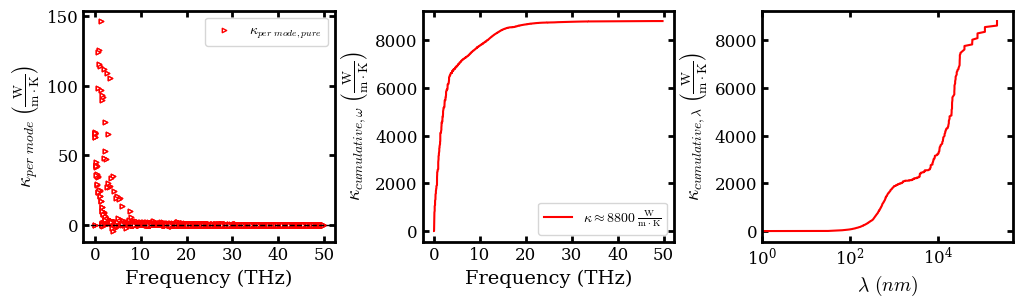

In [7]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.zeros([mean_free_path.shape[0], 3, 3])
kappa_tensor_iso = np.zeros([mean_free_path.shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor[:, i, j] = np.loadtxt(
    data_folder  + 'ALD_CNT/1_1_151/inverse/300/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

# Sum over the 0th dimension to recover 3-by-3 kappa matrix
# Note that 29.92 is the volume factor
kappa_matrix = 29.92 * kappa_tensor.sum(axis=0)
print("Thermal conductivity along z-axis: %.1f W m^-1 K^-1\n"
      % (np.diag(kappa_matrix)[2]))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = 29.92 * kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), 29.92 * kappa_tensor, prefactor=1.0)
lambda_sorted, kappa_cum_wrt_lambda = cumulative_cond_cal(
    mean_free_path_norm, 29.92 * kappa_tensor, prefactor=1.0)


# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='r', s=10, marker='>', label='$\kappa_{per \ mode, pure }$')
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
gca().set_xticks(np.arange(0, 60, 10))
legend(loc=1, fontsize=10)

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'r'
     , label=r"$\kappa \approx 8800 \;\frac{\rm{W}}{\rm{m}\cdot\rm{K}}$")
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=10)
gca().set_xticks(np.arange(0, 60, 10))

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted, kappa_cum_wrt_lambda, 'r')
xlabel(r'$\lambda \ (nm)$', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xscale('log')
subplots_adjust(wspace=0.35)
xlim([1e0, 5e5])
show()

# Full Simulations files for [PhysRevLett.127.025902](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.127.025902) can be found [here](10.5281/zenodo.4698466).